In [1]:
%matplotlib inline

import os
import sys

sys.path.append('../../../../')

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

In [2]:
from __future__ import annotations
from typing import Optional, Union

import torch
from torch.nn.modules.utils import _pair

import numpy as np

%load_ext autoreload
%autoreload 2

from computer_vision.slowfast.mmaction.datasets.transforms.loading import DecordInit, SampleFrames, DecordDecode
from computer_vision.slowfast.mmaction.datasets.transforms.processing import Resize, _init_lazy_of_proper, RandomCrop, CenterCrop, ThreeCrop
from computer_vision.slowfast.mmengine.utils.misc import is_tuple_of

data={'filename': 'D:/results/ucf101/demo.mp4', 'label': -1, 'start_index': 0, 'modality': 'RGB'}
Decord-init: results.keys()=dict_keys(['filename', 'label', 'start_index', 'modality', 'total_frames', 'video_reader', 'avg_fps'])
Sample frames: results.keys()=dict_keys(['filename', 'label', 'start_index', 'modality', 'total_frames', 'video_reader', 'avg_fps', 'frame_inds', 'clip_len', 'frame_interval', 'num_clips'])
Decode: results.keys()=dict_keys(['filename', 'label', 'start_index', 'modality', 'total_frames', 'video_reader', 'avg_fps', 'frame_inds', 'clip_len', 'frame_interval', 'num_clips', 'imgs', 'original_shape', 'img_shape'])
Resize: results.keys()=dict_keys(['filename', 'label', 'start_index', 'modality', 'total_frames', 'video_reader', 'avg_fps', 'frame_inds', 'clip_len', 'frame_interval', 'num_clips', 'imgs', 'original_shape', 'img_shape', 'scale_factor', 'keep_ratio'])
type(results['imgs'])=<class 'list'>, [(256, 340, 3), (256, 340, 3), (256, 340, 3), (256, 340, 3)], len(res

(-0.5, 2065.5, 3097.5, -0.5)

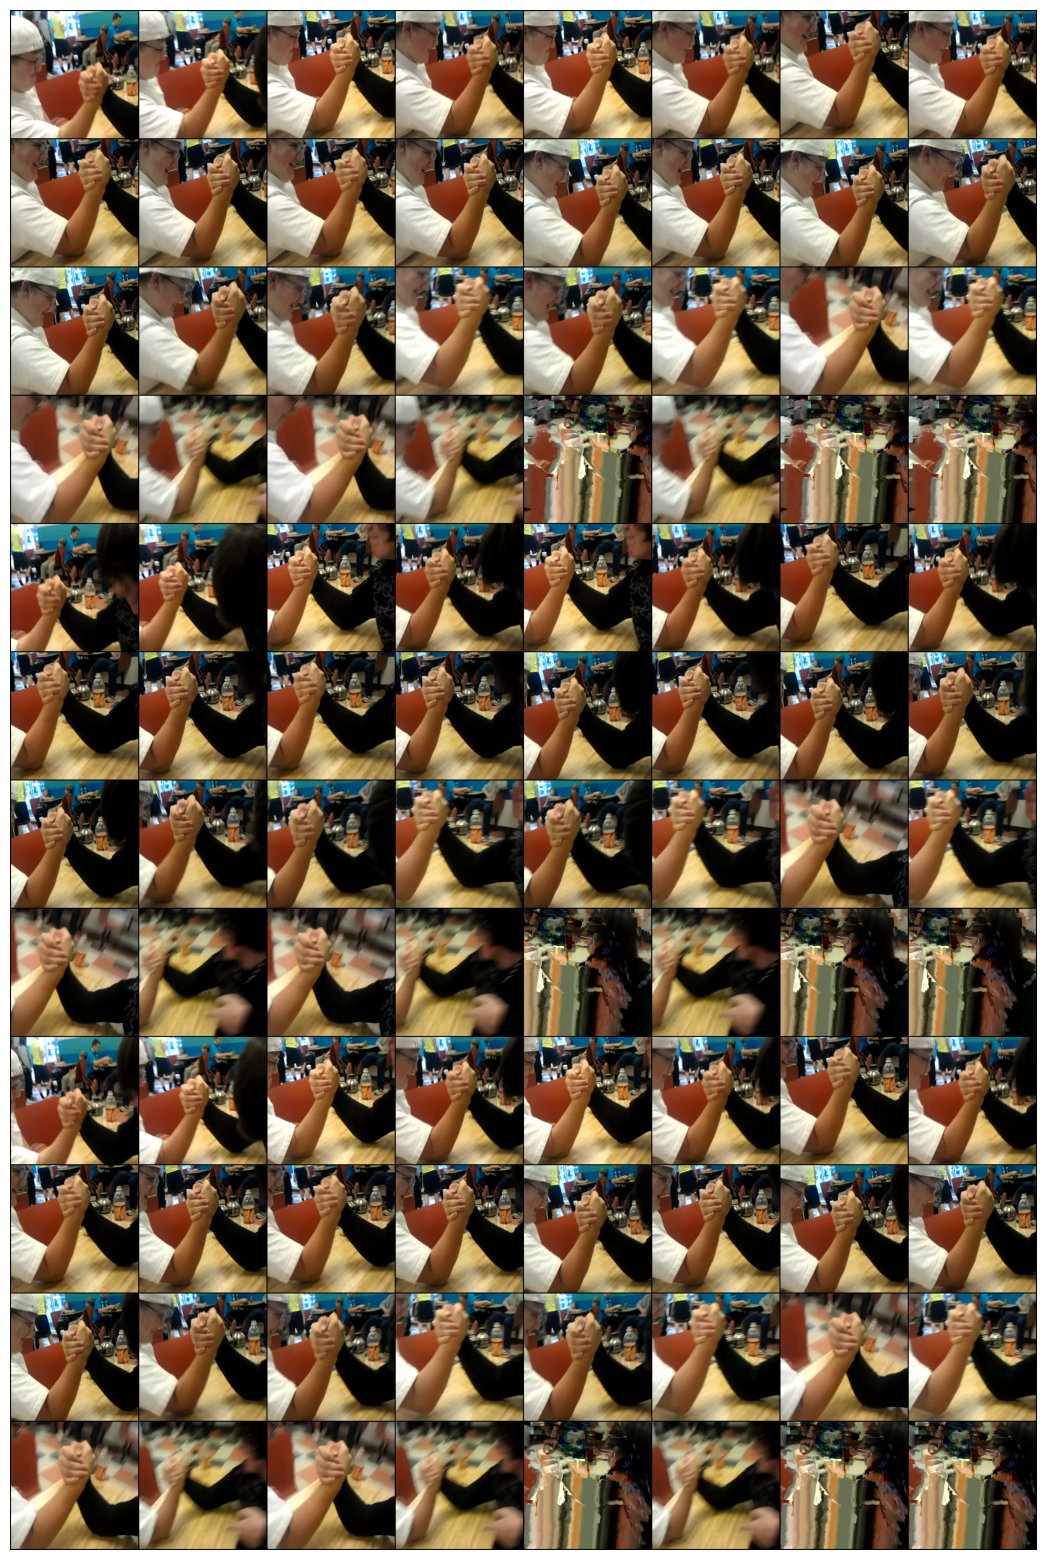

In [3]:
output_dirpath='D:/results/ucf101'
video_fpath=f'{output_dirpath}/demo.mp4'
assert os.path.isfile(video_fpath)

data=dict(filename=video_fpath, label=-1, start_index=0, modality='RGB')
print(f"{data=}")

# Create Decord
arguments={'type': 'DecordInit', 'io_backend': 'disk'}
arguments.pop('type')
decordinit=DecordInit(**arguments)
results=decordinit(data)
print(f'Decord-init: {results.keys()=}')

# Sample frames
arguments={'type': 'SampleFrames', 'clip_len': 32, 'frame_interval': 2, 'num_clips': 10, 'test_mode': True} #, 'target_fps':30}
arguments.pop('type')
sample_frames_op=SampleFrames(**arguments)
results=sample_frames_op(results)
print(f'Sample frames: {results.keys()=}')

decord_decode=DecordDecode()
results=decord_decode(results)
print(f'Decode: {results.keys()=}')

resize_op=Resize(scale=(-1, 256), keep_ratio=True, interpolation='bilinear', lazy=False) 
results=resize_op(results)
print(f'Resize: {results.keys()=}')
print(f"{type(results['imgs'])=}, {[x.shape for i, x in enumerate(results['imgs']) if i<4]}, {len(results['imgs'])=}")

crop_op=ThreeCrop(crop_size=256)
results=crop_op(results)
print(f'ThreeCrop: {results.keys()=}')
print(f"{type(results['imgs'])=}, {[x.shape for i, x in enumerate(results['imgs']) if i<4]}, {len(results['imgs'])=}")
print(f"{type(results['imgs'])=}, {[x.shape for i, x in enumerate(results['imgs']) if i<4]}, {len(results['imgs'])=}")
print(f"image size {[x.shape for i, x in enumerate(results['imgs']) if i < 7]}")

sampled_imgs=np.stack(results['imgs']).transpose(0,3,1,2)[::10]
print(f"{sampled_imgs.shape=}")
sampled_imgs=torch.from_numpy(sampled_imgs)
print(f"{sampled_imgs.shape=}")

_, ax=plt.subplots(figsize=(20,20))
ax.imshow(make_grid(sampled_imgs, nrow=8).permute(1,2,0))
ax.axis("off")